In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749154773.692141    3103 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749154773.698100    3103 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749154773.714161    3103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749154773.714192    3103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749154773.714194    3103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749154773.714196    3103 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 7: Working with Keras: A deep dive

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit, we are going to take a more detailed look at the Keras API.  A better understanding of some
of the details of the different `keras` workflows will help you to better understand the examples
and models we will develop in upcoming chapters.


## 7.3 Using built-in Training and Evaluation loops

There are similar more powerful and flexible ways to create workflows for training models.  Keras provides you with
different workflows for training models.  They can be as simple as calling `fit()` on your data, or as advanced as
writing a new training algorithm from scratch.

You are already familiar with the `compile()`, `fit()`, `evaluate()`, `predict()` workflow.  As a reminder,
here is how the simplest training loop workflow looks like again:

In [4]:
from tensorflow.keras.datasets import mnist

# create a model, separate function for reuse, example
# here again of using Functional API to create the model, though
# it is a simple sequential multi-class classification with a dense
# layer and some dropout regularization
def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model


# load and normalize the mnist data, reserviing some of the 60000
# in train set for validation
(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

# get new fresh untrained instance of the model
model = get_mnist_model()

# do the basic compile, fit, evaluate, predict training workflow
# compile the model by specifying it optimizer, loss function and metrics
# to monitor
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# use fit to train the model, providing validation data to monitor
# generalization during optimization
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))

# use evaluate to compute the loss and metrics on new data
test_metrics = model.evaluate(test_images, test_labels)

# use predict to compute classification probabilites on new data,
# this is what is conceputally used in production
predictions = model.predict(test_images)

I0000 00:00:1749154776.403791    3103 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9279 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/3


I0000 00:00:1749154779.271986    3185 service.cc:152] XLA service 0x778cbc003c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749154779.272026    3185 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1749154779.340982    3185 cuda_dnn.cc:529] Loaded cuDNN version 90300


  73/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5978 - loss: 1.2620

I0000 00:00:1749154780.554279    3185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8631 - loss: 0.4436 - val_accuracy: 0.9590 - val_loss: 0.1437
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9496 - loss: 0.1690 - val_accuracy: 0.9651 - val_loss: 0.1207
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9626 - loss: 0.1286 - val_accuracy: 0.9707 - val_loss: 0.1098
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9661 - loss: 0.1205
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


There are a couple of very useful and common ways you will use to customize this basic training loop workflow:
- Provide your own custom metrics.
- Pass **callbacks** to the `fit()` method to schedule actions to be taken at specific
  points during training.

### 7.3.1 Writing your own metrics

A Keras metric is a subclass of the `keras.metrics.Metric` class.  Like layers, a metric has an internal
state stored in TensorFlow variables.  Unlike layers, these are not updated via backpropagation, so you have to write
the state-update logic yourself.  This happens in the `update_state()` member method.

For example, here's a simple custom metric that measures the root mean squared error (RMSE).  There are of course
already root mean squared error metrics, along with mean squared error, mean absolute error, etc.  This is only to
illustrate how to add in a new metric for evaluation.

In [5]:
class RootMeanSquaredError(keras.metrics.Metric):

    # Define the state variables in the constructor.  Like for layers you have
    # access to the add_weight() method.
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(name="total_samples", initializer="zeros", dtype="int32")

    # Implement the state update logic.  The y_true argument
    # is the targets (or labels) for one batch, while y_pred represents
    # the corresponding predictions.  
    def update_state(self, y_true, y_pred, sample_weight=None):
        print('y_true.shape: ', y_true.shape)
        print('y_pred.shape: ', y_pred.shape)
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[1])
        print('y_true.shape (after one_hot encoding): ', y_true)
        mse = tf.reduce_sum(tf.square(y_true - y_pred))
        print('mse: ', mse)
        self.mse_sum.assign_add(mse)
        num_samples = tf.shape(y_pred)[0]
        print('num_samples: ', num_samples)
        print('\n\n')
        self.total_samples.assign_add(num_samples)

    # you can use the result method to return the current calculation of the metric
    def result(self):
        return tf.sqrt(self.mse_sum / tf.cast(self.total_samples, tf.float32))

    # also it is common to reuse the metric instance rather than recreating a new one
    # for performance reasons presumably, so override method for that
    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0)    

Custom metrics can be used just like built-in ones, though notice built in ones can be specified using a string constant.  But
simply pass in an instance of an object that inherits from `Metric` to use it.

### 7.3.2 Using callbacks

A callback is an object (a class instance implementing specific methods) that is
passed to the model in the call to fit() and that is called by the model at various
points during training.  Callbacks are very common ways to get more control
and insight into your model training.  They are commonly used for:

- **Model checkpointing** Saving the current state of the model to hard disk
  in a file at different points during training.
- **Early stopping** Interrupting training when the validation loss is no longer
  improving, and saving the best model.  For long training runs you might not
  want to first do a run to find when training should stop and then rerun
  training up to that point, for example if it takes days or weeks of training
  to arrive at minimal validation loss.
- **Dynamically adjusting the values of certain parameters during training**  Such
  as the learning rate of the optimizer.  In some advanced scenarios you will know
  better than the advanced optimizer where and when learning rates should be adjusted.
- **Logging training and validation metrics during training, or visualizing
  representations learned by the model as they're updated** - The `fit()` progress
  bar that you see by default is actually this type of callback.

#### The `EarlyStopping` and `ModelCheckpoint` callbacks

The `EarlyStopping` callback interrupts training once a target metric being monitored
has stopped improving for a fixed number of epochs.  For instance, instead
of doing a first run to determine by hand when validation loss stops decreasing,
you can use this callback to do it automatically if validation loss hasn't decreased
for some number of epochs.  

This callback is typically used with the `ModelCheckpoint` callback, which lets you
continually save the model during training, or only save the current best model
seen so far.

Here is an example of using `EarlyStopping` to stop training once the validation
accuracy metric stops improving.  The `patience` parameter indicates that at least
2 consecutive epochs of training where validation accuracy stays the same or gets worse
need to pass before the callback stops the training.  

The `ModelCheckpoint` callback will default to checking and saving the best model weights to a file
every epoch.  We set the destination path to the `../models` subdirectory of this
project.

In [6]:
# callbacks are passed to the model ia the callbacks argument in fit(),
# which takes a list of callbacks.  As you see here you can pass in any
# number of callbacks.
callbacks_list = [
    # interrupts training when validation accuracy improvement stops.
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", # monitoring the validation accuracy metric
        patience=2,             # interrupts training when accuracy has stopped improving for 2 epochs
    ),
    # saves the current weights after every epoch
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch07-callbacks-example-best-model.keras",  # path to the destination model file storage location
        monitor="val_loss",    # these two options mean actually we only overwrite the model file if 
        save_best_only=True,   # val_loss is better than the last model saved
    )
]


model = get_mnist_model()

# since we have a callback monitoring accuracy, it needs to be
# one of the metrics monitored, or else the training won't work
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# likewise since we are monitoring validation loss and validation
# accuracy in the callbacks, we have to pass in validation data to
# use when fitting the model
model.fit(train_images, train_labels,
          epochs=20,
          callbacks=callbacks_list,
          validation_data=(val_images, val_labels))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8661 - loss: 0.4440 - val_accuracy: 0.9580 - val_loss: 0.1459
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9519 - loss: 0.1588 - val_accuracy: 0.9678 - val_loss: 0.1161
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9626 - loss: 0.1326 - val_accuracy: 0.9731 - val_loss: 0.1000
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9689 - loss: 0.1153 - val_accuracy: 0.9751 - val_loss: 0.0951
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9736 - loss: 0.1035 - val_accuracy: 0.9758 - val_loss: 0.0944
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9745 - loss: 0.0892 - val_accuracy: 0.9786 - val_loss: 0.0863
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9762 - loss: 0.0843 - val_accuracy: 0.9770 - val_loss: 0.0895
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9777 - loss: 0.0764 - 

There is of course some randomness, but usually when you run this the valadation accuracy will reach about 0.98 and will stop improving around
epoch 10 or so, at which point the training will be ended early (the number of epochs specified for this run should be 20).  Also
if you look in the `../models` subdirectory you should see the file with the saved weight parameters of the model.  This should be
the model at the epoch where validation loss was the smallest, as that is what we specify to keep in the `ModelCheckpoint` callback.

Note that you can always save models manually after training as well, just call:

In [7]:
# lets save the last model at end of training by hand
model.save('../models/ch07-callback-example-final-model.keras')

And for example, if you wanted to load the model that achieved the best validation loss, to evaluate it further, you could:

In [8]:
model = keras.models.load_model('../models/ch07-callbacks-example-best-model.keras')

test_metrics = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.1030


### 7.3.3 Writing your own callbacks

Callbacks are implemented by subclassing the `keras.callbacks.Callback` class. You can then implement any number
of the following transparently named methods, which are called at various points during training:

```python
# called at the start of every epoch
on_epoch_begin(epoch, logs)

# called at the end of every epoch
on_epoch_end(epoch, logs)

# called right before processing each batch
on_batch_begin(batch, logs)

# called right after processing each batch
on_batch_end(batch, logs)

# called at the start of training
on_train_begin(logs)

# called at the end of training
on_train_end(logs)
```

The `logs` argument is a dictionary containing information about the previous batch, epoch or training
run.

The following is an example of creating a custom callback, subclassed from the `keras.callbacks.Callback` object.
We save a list of per-batch loss values during training and create and saves
a figure of these values at the end of each epoch.

In [9]:
class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    # there are multiple batches each epoch, we append the training loss
    # after each batch is processed and append to list
    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    # at end of each epoch, create a figure and save it, showing the loss for each
    # individual batch during this epoch
    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
        label="Training loss for each batch")
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"../figures/plot_at_epoch_{epoch}")
        self.per_batch_losses = []

We can pass our callback in just like any predefined callback.  For example, fitting an mnist
model again:

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8608 - loss: 0.4551 - val_accuracy: 0.9558 - val_loss: 0.1530
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9513 - loss: 0.1685 - val_accuracy: 0.9656 - val_loss: 0.1186
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9624 - loss: 0.1330 - val_accuracy: 0.9703 - val_loss: 0.1136
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9670 - loss: 0.1129 - val_accuracy: 0.9734 - val_loss: 0.1001
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9724 - loss: 0.1022 - val_accuracy: 0.9762 - val_loss: 0.0948
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9742 - loss: 0.0930 - val_accuracy: 0.9757 - val_loss: 0.1011
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9753 - loss: 0.0869 - val_accuracy: 0.9774 - val_loss: 0.0975
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9781 - loss: 0.0793 - 

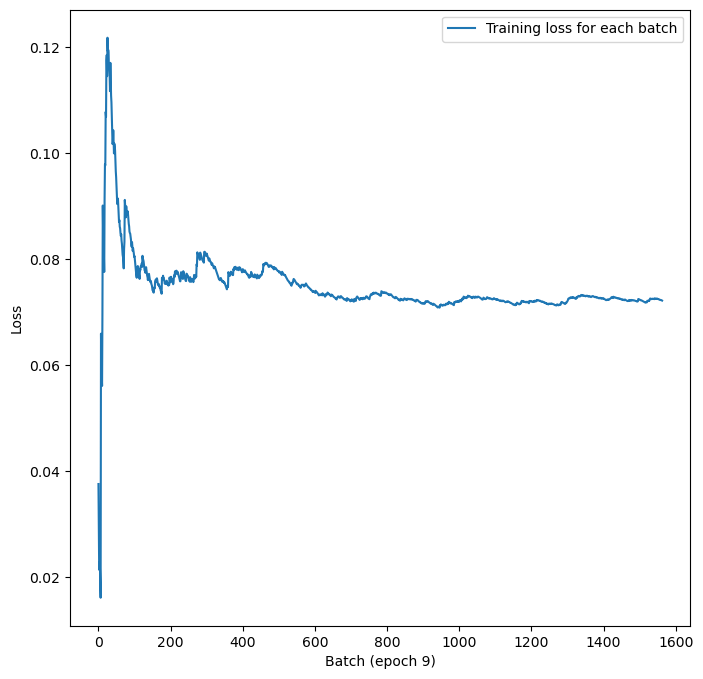

In [10]:
model = get_mnist_model()

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# use our own callback to get plots of per batch loss each epoch.
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=[LossHistory()],
          validation_data=(val_images, val_labels))

![The loss per batch for last epoch of training](../figures/plot_at_epoch_0.png)

Note that internally epochs are numbered using 0 based indexing, so the figures are named
`plot_at_epoch_0` through `plot_at_epoch_9`.  The callback used by `fit()` adds one so refers
to these as epochs 1-10.  You should find all of the plots generated in the `../figures` subdirectory of the project.  

### 7.3.4 Monitoring and visualization of training with TensorBoard

To do good research or develop good models, you need rich, frequent feedback about
what’s going on inside your models during your experiments.  The TensorBoard
browser-based monitoring tool is meant to help you more quickly evaluate
results and performance from training runs of Keras deep learning models.

TensorBoard (www.tensorflow.org/tensorboard) is a browser-based application that
you can run locally. It’s the best way to monitor everything that goes on inside your
model during training. With TensorBoard, you can

- Visually monitor metrics during training
- Visualize your model architecture
- Visualize histograms of activations and gradients
- Explore embeddings in 3D

The easiest way to use TensorBoard with a Keras model and the `fit()` method is to
use the `keras.callbacks.TensorBoard` callback.  In the simplest case, just specify where you
want the callback to write logs, and you are ready to go:

In [11]:
model = get_mnist_model()

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# ask for log files to be gathered in the ../logs subdirectory of project
tensorboard = keras.callbacks.TensorBoard(
    log_dir="../logs",)

model.fit(train_images, train_labels,
          epochs=10,
          validation_data=(val_images, val_labels),
          callbacks=[tensorboard])


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8643 - loss: 0.4533 - val_accuracy: 0.9550 - val_loss: 0.1488
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9490 - loss: 0.1702 - val_accuracy: 0.9681 - val_loss: 0.1150
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9610 - loss: 0.1333 - val_accuracy: 0.9702 - val_loss: 0.1050
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9687 - loss: 0.1102 - val_accuracy: 0.9746 - val_loss: 0.1034
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9722 - loss: 0.1008 - val_accuracy: 0.9759 - val_loss: 0.0925
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9756 - loss: 0.0891 - val_accuracy: 0.9783 - val_loss: 0.0885
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0828 - val_accuracy: 0.9790 - val_loss: 0.0908
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9779 - loss: 0.0775 - 

Once the model starts running, it will write logs at the target location.  You can launch a
local TensorBoard server using the following command:

**Note**: The following shows running the tensorboard server using our classes Docker / DevContainer
setup.  Open a terminal running in your DevContainer and perform:

```
vscode ➜ /workspaces/nndl (main) $ tensorboard --logdir logs --bind_all
...
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

TensorBoard 2.19.0 at http://a95932961387:6006/ (Press CTRL+C to quit)

```

The `--bind_all` flag is needed when running from inside of a container.  If you are using an environment 
installed directly on your host system (not in a container) you probably don't need the bind all flag.

The TensorBoard server opens up its service on port 6006 by default.  In VSCode running a DevContainer
you will need to open up port 6006 by hand.  In your Terminal view, open the Ports tab and use the
"Add Port" button to open up and forward this port to your host machine.  Alternatively you can
add port 6006 to the list of `forwardedPorts` in your `devcontainer.json` file.

## Summary

Some of the important things to remember about writing your own metrics and callbacks and using TensorBoard:

<font color='blue'>

- Keras provides you with different workflows for training models.
- If you are doing something out of the ordinary you might need your own metric.  Subclass the `keras.metrics.Metric` class
  and provide `update_state()`, `result()` and `reset_state()` member methods.
- Callbacks can allow you to get better insight and control of your model training during optimization.
- A callback is an object that is passed to the modell in the call to `fit()` that is called at various points during training.
  - **Model checkpointing** save current state of model at different points of training
  - **Early stopping** implement early stopping automatically for long training runs.
  - **Dynamically adjust parameters during learning** for example adjust learning rate.
- TensorBoard can allow you to monitor a long training run in real time.